<a href="https://colab.research.google.com/github/hoanganh1105/ai-ambulance-coordinator/blob/main_pipeline/notebooks/Main_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cài đặt

In [ ]:
!git clone -b main_pipeline https://github.com/hoanganh1105/ai-ambulance-coordinator.git
%cd ai-ambulance-coordinator
!pip install -r requirements.txt

In [ ]:
import kagglehub
disease_classifier_train_dataset = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset", path="Final_Augmented_dataset_Diseases_and_Symptoms.csv")
print("Path to disease dataset:", disease_classifier_train_dataset)
traffic_estimator_train_dataset = kagglehub.dataset_download("guriya79/understanding-delhi-traffic-patterns", path="delhi_traffic_features.csv")
print("Path to traffic dataset:", traffic_estimator_train_dataset)

## Cấu hình môi trường

Cấu hình dùng để dự báo tình trạng giao thông.

In [6]:
time_of_day = "Morning Peak"    # "Morning Peak" / "Afternoon" / "Evening Peak" / "Night"
day_of_week = "Weekday"         # "Weekday" / "Weekend"
weather_condition = "Rain"      # "Clear" / "Rain" / "Fog" / "Heatwave"

## Khởi tạo mô hình

In [ ]:
from modules.core.disease_classifier import *
from modules.core.map_router import *
from modules.core.patient_prioritizer import *
from modules.core.traffic_estimator import *

route_planner = MapRouter()
traffic_estimator = TrafficEstimator()
disease_classifier = DiseaseClassifier()
patient_prioritizer = PatientPrioritizer()

print("=== Training traffic_estimator from dataset ===\n")
traffic_estimator.train(traffic_estimator_train_dataset)
print("=== Training disease_classifier from dataset ===\n")
disease_classifier.train(disease_classifier_train_dataset)
print("=== Loading knowledgebase for patient_prioritizer ===\n")
patient_prioritizer.load_knowledge_base("features/knowledgebase.txt")

print("Done ✅.")

## Xử lý chính

Dự báo mức độ kẹt xe bằng `traffic_estimator` và cập nhật trọng số cho các cạnh theo công thức `weight = length * (1 + alpha * jam_level)` để tiến hành tìm đường đi ngắn nhất ở các bước sau.

In [9]:
def density_level_func(data):
  road_type = data.get("highway")
  jam_level = traffic_estimator.estimate_traffic_density_level(time_of_day,
                                                               day_of_week,
                                                               weather_condition,
                                                               road_type)
  return jam_level

def weight_func(data, alpha = 0.5):
  length = data.get("length")
  jam_level = data.get("density_level")
  return length * (1 + alpha * jam_level)

route_planner.add_edges_attribute("density_level", density_level_func)
route_planner.add_edges_attribute("weight", weight_func)

Dưới đây là hàm xử lý các yêu cầu xe cứu thương từ các bệnh nhân. Hệ thống sẽ ưu tiên những bệnh nhân có triệu chứng nghiêm trọng nhất, sau đó là các bệnh nhân có bệnh được dự đoán nghiêm trọng nhất và cuối cùng là ưu tiên bệnh nhân gần nhất.

In [ ]:
def process_patients_requests(ambulance_coord: tuple[float, float], patients: list[Patient]):
  # Dự đoán bệnh của bệnh nhân
  for p in patients:
    p.predicted_disease = disease_classifier.predict(p.symptoms)

  # Danh sách các bệnh nhân được ưu tiên nhất dựa trên triệu chứng và bệnh
  most_prior_patients = patient_prioritizer.get_most_prioritized_patients(patients)

  # Tìm đường đi tới các bệnh nhân đó
  routes = [route_planner.optimal_path(ambulance_coord, p.position) for p in most_prior_patients]

  # Ưu tiên bệnh nhân gần nhất
  nearest = min(routes, key=lambda x: x[1])
  chosen_patient = most_prior_patients[routes.index(nearest)]
  path = nearest[0]

  # Show kết quả
  print("\n=== Kết quả ===")
  print("\nMức độ kẹt xe từ 0 (xanh lá) đến 3 (đỏ)")
  route_planner.show_map(show_density=True)
  print(f"\nVị trí xe cứu thương: {ambulance_coord}")
  from tabulate import tabulate
  headers = ["ID", "Vị trí", "Triệu chứng", "Chẩn đoán", "Được chọn"]
  rows = [[p.id, p.position, ", ".join(p.symptoms), p.predicted_disease, '*' if p is chosen_patient else ''] for p in patients]
  print(tabulate(rows, headers=headers, tablefmt="grid"))
  route_planner.show_map(route=path, org=ambulance_coord, dests=[p.position for p in patients])
  print(f"\nĐường đi: {path}")

  return path

## Giao diện tương tác

Thực hiện theo các bước sau:

1. Chọn vị trí xe cứu thương
2. Thêm một số lượng bệnh nhân tuỳ ý bằng cách lặp lại cách bước:
  - Chọn vị trí bệnh nhân
  - Liệt kê các triệu chứng
  - Nhấn "Thêm bệnh nhân"
3. Nhấn "Kết thúc và trả kết quả"
    

Nearest nodes: source=267075196, target=1328248383

=== Kết quả ===

Vị trí xe cứu thương: (28.61308268218122, 77.22753524780275)
+------+-----------------------------------------+------------------------------------------------------------+-----------------------+-------------+
|   ID | Vị trí                                  | Triệu chứng                                                | Chẩn đoán             | Được chọn   |
+======+=========================================+============================================================+=======================+=============+
|    8 | (28.60878772988515, 77.18084335327148)  | irregular heartbeat, shortness of breath, sharp chest pain | aortic valve disease  | *           |
+------+-----------------------------------------+------------------------------------------------------------+-----------------------+-------------+
|    9 | (28.614815683378463, 77.23474502563478) | sore throat, hoarse voice                                  | croup   

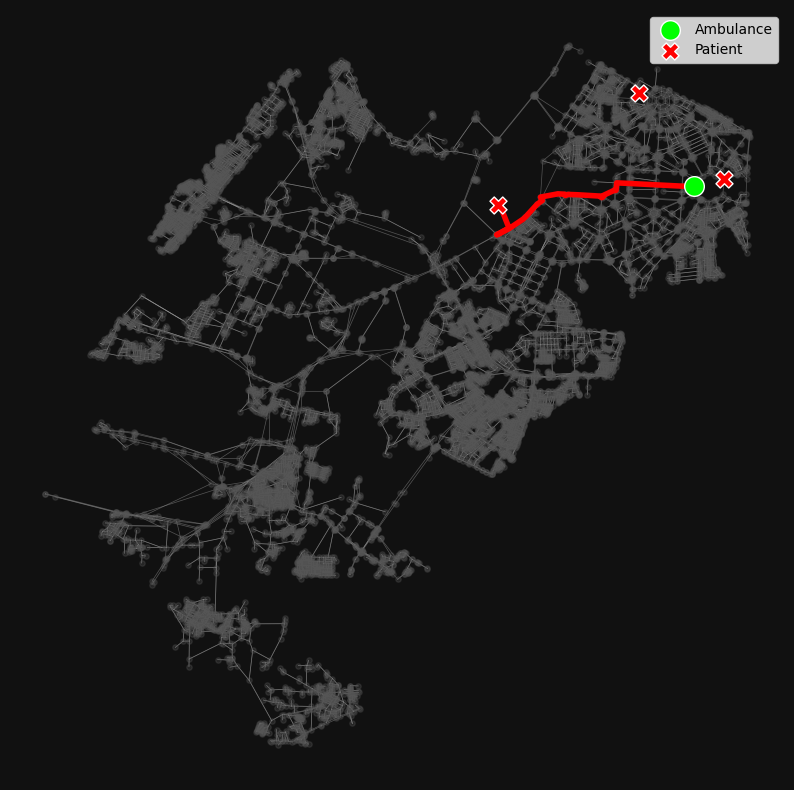


Đường đi: [(28.6130207, 77.2276662), (28.6131362, 77.2248482), (28.6131403, 77.2247644), (28.6134419, 77.2185268), (28.6134521, 77.2184671), (28.6137551, 77.2122049), (28.6137596, 77.2121071), (28.6138946, 77.2091896), (28.6128911, 77.2091292), (28.6121999, 77.2090484), (28.6121335, 77.2089191), (28.6121348, 77.2088429), (28.6122346, 77.208697), (28.6109861, 77.2059601), (28.6107749, 77.2059839), (28.6105751, 77.2058349), (28.6105086, 77.2055836), (28.6108599, 77.2052212), (28.6111644, 77.1998584), (28.6111845, 77.1992757), (28.6111966, 77.1989504), (28.6112219, 77.1982187), (28.6112433, 77.1975628), (28.6109842, 77.1969727), (28.6112887, 77.1967958), (28.6113717, 77.195166), (28.6106308, 77.1910499), (28.6098856, 77.1915117), (28.6098205, 77.1914498), (28.6096576, 77.1912026), (28.6089804, 77.1902452), (28.6075904, 77.188931), (28.6060854, 77.1874934), (28.6060281, 77.1874331), (28.6055279, 77.1868539), (28.6034408, 77.1836422), (28.6034019, 77.1835655), (28.60212, 77.1810366), (28.6

In [ ]:
from modules.ui.dispatch_ui import *
create_dispatch_interface(route_planner.place, list(disease_classifier.symptoms_vocab), process_patients_requests)

In [ ]:
# %cd ..
# !rm -rfv ai-ambulance-coordinator